# Gradient Boosting Regressor - Solar Wastage
Train and evaluate a GradientBoostingRegressor model using features_regression_ready.csv.

In [1]:
# Import required libraries
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output
import json
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
# Define file paths (relative to notebooks/training/)
DATA_PATH = Path('../../data/processed/features_regression_ready.csv')  # Input data
MODEL_PATH = Path('../../models/gradient_boosting_pipeline.pkl')  # Output model
METRICS_PATH = Path('../../models/gradient_boosting_metrics.json')  # Output metrics
RANDOM_STATE = 42  # For reproducibility

In [3]:
# Load and prepare data
df = pd.read_csv(DATA_PATH)
target_col = 'wasted_energy_kwh'  # Target variable to predict

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Define column types for preprocessing
categorical_cols = ['household', 'season', 'district']
numerical_cols = [c for c in X.columns if c not in categorical_cols]
X.head()

,daily_pv_kwh,daily_load_kwh,household,year,month,day,quarter,day_of_week,day_of_year,week_of_year,...,load_rolling_mean_14d,pv_rolling_std_14d,wastage_rolling_mean_14d,pv_rolling_mean_30d,load_rolling_mean_30d,pv_rolling_std_30d,wastage_rolling_mean_30d,district,irradiance,temp
0,0.010838,0.018602,residential1,2015,5,21,2,3,141,21,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,Colombo,5.6695,26.91
1,0.555957,0.214720,residential1,2015,5,22,2,4,142,21,...,0.018602,0.000000,0.0,0.010838,0.018602,0.000000,0.0,Colombo,6.0698,27.17
2,1.382767,0.409031,residential1,2015,5,23,2,5,143,21,...,0.116661,0.385457,0.0,0.283398,0.116661,0.385457,0.0,Colombo,4.5922,27.20
3,2.177085,0.574465,residential1,2015,5,24,2,6,144,21,...,0.214118,0.690768,0.0,0.649854,0.214118,0.690768,0.0,Colombo,6.2059,27.32
4,2.962496,0.684174,residential1,2015,5,25,2,0,145,22,...,0.304204,0.949324,0.0,1.031662,0.304204,0.949324,0.0,Colombo,6.1730,27.30


In [4]:
# Define preprocessing pipelines for different column types
# Categorical: impute missing values with most frequent, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Numerical: impute missing values with median, then standardize
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Combine transformers into a single preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, categorical_cols),
    ('num', numerical_transformer, numerical_cols)
])

In [5]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [6]:
# Create Gradient Boosting regressor model
model = GradientBoostingRegressor(random_state=RANDOM_STATE)

# Build pipeline: preprocessing -> model
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

# Train the model and make predictions
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [7]:
# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)            # R-squared (coefficient of determination)
mae = mean_absolute_error(y_test, y_pred) # Mean Absolute Error
rmse = root_mean_squared_error(y_test, y_pred)  # Root Mean Squared Error

# Display results
print('GradientBoostingRegressor Results')
print('=' * 50)
print(f'R2:   {r2:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'RMSE: {rmse:.4f}')

GradientBoostingRegressor Results
R2:   0.9987
MAE:  0.8504
RMSE: 4.5064


In [8]:
# Save metrics and trained model
metrics = {'R2': float(r2), 'MAE': float(mae), 'RMSE': float(rmse)}

# Create models directory if it doesn't exist
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

# Save pipeline (includes preprocessor + model)
joblib.dump(pipeline, MODEL_PATH)

# Save metrics as JSON
with open(METRICS_PATH, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

print('Saved:', MODEL_PATH, METRICS_PATH)

Saved: ..\..\models\gradient_boosting_pipeline.pkl ..\..\models\gradient_boosting_metrics.json


## Plot Actual vs Predicted

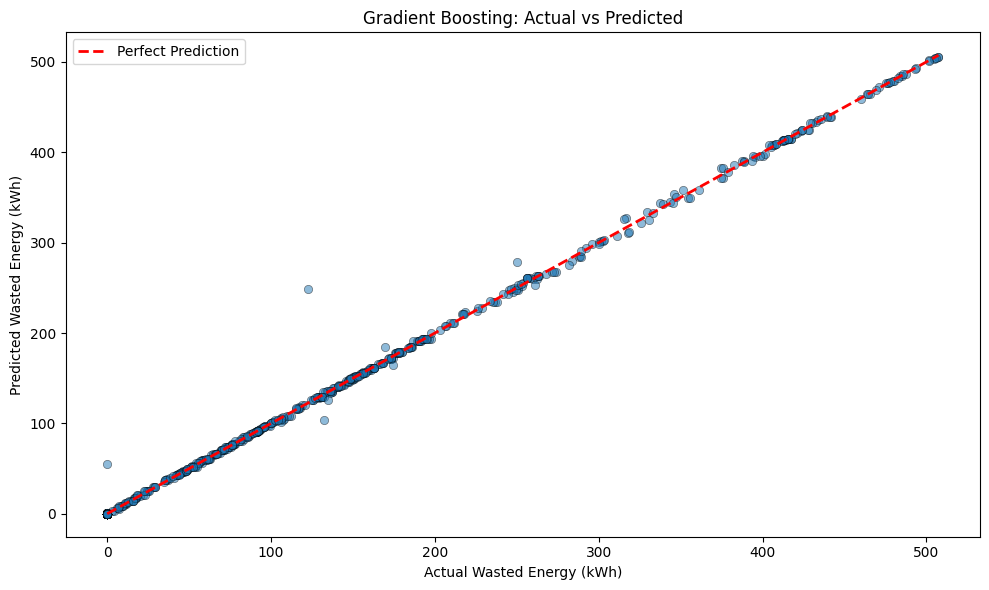

In [9]:
# Plot Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidths=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Wasted Energy (kWh)')
plt.ylabel('Predicted Wasted Energy (kWh)')
plt.title('Gradient Boosting: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.savefig('../../results/gradient_boosting_actual_vs_predicted.png', dpi=150)
plt.show()

## Feature Importance

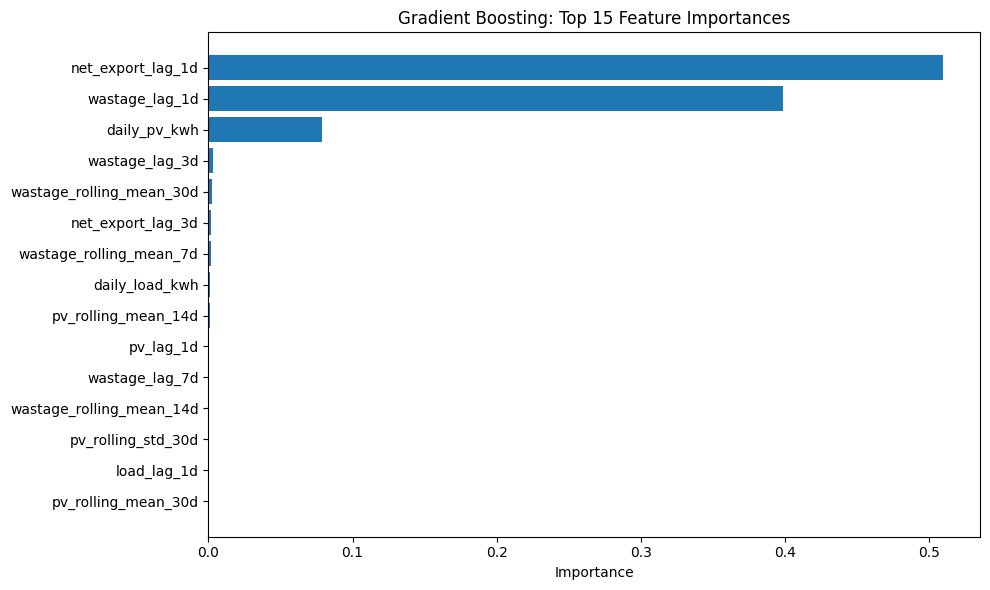

In [10]:
# Extract feature names after one-hot encoding
cat_features = pipeline.named_steps['preprocessor'].named_transformers_['cat']\
    .named_steps['onehot'].get_feature_names_out(categorical_cols).tolist()
all_features = cat_features + numerical_cols

# Get feature importances from the trained model
importances = pipeline.named_steps['model'].feature_importances_

# Create DataFrame and sort by importance
feat_imp = pd.DataFrame({'feature': all_features, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(15)

# Plot top 15 feature importances
plt.figure(figsize=(10, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Gradient Boosting: Top 15 Feature Importances')
plt.tight_layout()
plt.savefig('../../results/gradient_boosting_feature_importance.png', dpi=150)
plt.show()